# 4.5. Concise Implementation of Softmax Regression 

이전 장에서는 softmax regression의 내부 동작을 이해하기 위해 다음 기능을 직접 구현했다. 

- Weight와 bias 
- Softmax 
- Cross-Entropy Loss 
- SGD 업데이트 
- Training loop

이번 장에서는 같은 모델을 PyTorch의 내장 기능으로 구현한다.

## 0. 기본 설정

PyTorch를 불러오고 현재 환경을 확인

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt 
import torch 
from torch import nn 
from torch.utils.data import DataLoader 
from torchvision import datasets, transforms

torch.manual_seed(42) 

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


## 1. Fashion-MNIST 데이터 준비 

Fashion-MNIST 이미지는 이런 shape을 가진다. 

    [channel, height, width] 
    [1, 28, 28] 

Softmax regression에서는 이미지를 한 줄로 펼쳐서 사용한다. 

1 × 28 × 28 = 784 따라서 이미지 한 장은 784개의 feature가 된다. 

Fashion-MNIST에는 10개의 class가 있으므로 모델은 이미지마다 10개의 점수를 출력해야 한다.

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST( 
    root="./data", 
    train=True, 
    transform=transform, 
    download=True 
) 

test_dataset = datasets.FashionMNIST( 
    root="./data", 
    train=False, 
    transform=transform, 
    download=True
) 

batch_size = 256

train_loader = DataLoader( 
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=0 
) 

test_loader = DataLoader( 
    test_dataset, 
    batch_size=batch_size,
    shuffle=False, 
    num_workers=0
) 

print("훈련 데이터 개수:", len(train_dataset)) 
print("테스트 데이터 개수:", len(test_dataset))

훈련 데이터 개수: 60000
테스트 데이터 개수: 10000


In [ ]:
X, y = next(iter(train_loader)) 

print("X shape:", X.shape) # 이미지 256장
print("y shape:", y.shape) # y에는 이미지 정답 256개

X shape: torch.Size([256, 1, 28, 28])
y shape: torch.Size([256])


## 2. 모델 정의

전 장에서는 forward를 직접 만들었는데 이번엔 PyTorch를 사용한다.

    nn.Flatten()
    nn.Linear(784)

`nn.Flatten()`은 이미지 shape를 이렇게 쓴다.

    [batch_size, 1, 28, 28]
    [batch_size, 784]

`nn.Linear(784, 10)`은 이 계산을 수행한다.

$$ O = XW + b $$

각 Tensor의 shape는 이렇다.

    X: [batch_size, 784]
    W: [10, 784]
    b: [10]

출력 shape는

    logits: [batch_size, 10]

In [4]:
model = nn.Sequential( 
    nn.Flatten(), 
    nn.Linear(28 * 28, 10) 
) 

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)


In [6]:
X_batch, y_batch = next(iter(train_loader)) 

logits = model(X_batch) 

print("입력 shape:", X_batch.shape) 
print("출력 shape:", logits.shape) # 이미지가 256개 class 10개 각 이미지마다 10개 class 점수 출력
print("첫 번째 데이터의 logits:") # 음수가 나올수 있고 합이 1이 아니고, 값의 범위가 없다. 확률 X
print(logits[0]) # 이런 softmax 이전 점수를 logits라고 함

print("logits 합:", logits[0].sum()) 
print("logits 최솟값:", logits[0].min()) 
print("logits 최댓값:", logits[0].max())

입력 shape: torch.Size([256, 1, 28, 28])
출력 shape: torch.Size([256, 10])
첫 번째 데이터의 logits:
tensor([ 0.2408, -0.1583, -0.0905, -0.0837, -0.0555, -0.1463,  0.1779, -0.0954,
         0.0992, -0.0809], grad_fn=<SelectBackward0>)
logits 합: tensor(-0.1928, grad_fn=<SumBackward0>)
logits 최솟값: tensor(-0.1583, grad_fn=<MinBackward1>)
logits 최댓값: tensor(0.2408, grad_fn=<MaxBackward1>)


## 3. LazyLinear

D2L에선 이런계층을 쓴다.

    nn.LazyLinear(10)

`nn.LazyLinear`는 입력 feature 수를 처음 데이터를 받을 때 자동으로 결정한다.

따라서 다음처럼 입력 크기 784를 직접 적지 않아도 된다.

그런데 입력 크기가 784라는 걸 알고 있으므로 처음 학습할때는 써주는게 더 명확하다.

    nn.LazyLinear(784, 10)

`LazyLinear`는 입력 feature 수를 미리 알기 어려울 때 편리하다.

In [ ]:
lazy_model = nn.Sequential( 
    nn.Flatten(), 
    nn.LazyLinear(10) # 첫번째 forward가 실행되기 전까지 입력 feature수를 모른다.
) # 첫번째 데이터가 들어오면 입력 크기를 확인하고 내부 weight shape를 자동으로 결정함.

lazy_logits = lazy_model(X_batch) 

print(lazy_model) 
print("출력 shape:", lazy_logits.shape)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)
출력 shape: torch.Size([256, 10])


In [8]:
linear_layer = lazy_model[1] 

print("weight shape:", linear_layer.weight.shape) 
print("bias shape:", linear_layer.bias.shape)

weight shape: torch.Size([10, 784])
bias shape: torch.Size([10])


## 4. Cross-Entropy Loss

전 장에서 다음 순서로 loss를 직접 계산해봤다.

    logits
    -> softmax
    -> 정답 class 확률 선택
    -> -log
    -> 평균

이번에는 PyTorch의 `nn.CrossEntropyLoss()`를 사용해보자

    loss_fn = nn.CrossEntropyLoss()

`CrossEntropyLoss`에 softmax 결과를 넣지 않고 softmax전 logits을 넣는다.

    logits = model(X)
    loss = loss_fn(logits, y)

In [ ]:
loss_fn = nn.CrossEntropyLoss() # 내부적으로
# log-softmax + negative log likelihood 계산으로 처리한다.
# softmax랑 log를 따로 계싼하면 overflow나 underflow가 발생할 수 있어서 안정적으로 계산한다.

loss = loss_fn(logits, y_batch)

print("loss:", loss)

loss: tensor(2.3278, grad_fn=<NllLossBackward0>)


### Softmax는 언제 사용할까

학습할 떄는 softmax를 직접 적용하지 않는다.

    logits = model(X)
    loss = loss_fn(logits, y)

하지만 모델이 각 class에 부여한 확률을 직접 확인하고 싶다면 학습이 아닌 예측 단계에서 softmax를 사용할 수 있다.

    probabilities = torch.softmax(logits, dim=1)

예측 class만 필요하다면 softmax도 필요 없다.

    predictions = logits.argmax(dim=1)

softmax를 적용해도 가장 큰 값의 위치는 변하지 않기 때문이다.

In [10]:
probabilities = torch.softmax(logits, dim=1) 

prediction_from_logits = logits.argmax(dim=1) 
prediction_from_probabilities = probabilities.argmax(dim=1) 

print("첫 번째 확률 합:", probabilities[0].sum()) 

print( "두 예측 결과가 같은가:", torch.equal( prediction_from_logits, prediction_from_probabilities ) )

첫 번째 확률 합: tensor(1.0000, grad_fn=<SumBackward0>)
두 예측 결과가 같은가: True


## 5. Optimizer

전장에서 SGD업데이트를 직접 구현했었다.

    param -= learning_rate * param.grad
    param.grad.zero()

이번에는 PyTorch의 optimizer를 사용한다.

    torch.optim.SGD

Optimizer는 모델의 파라미터 관리, gradient를 이용한 파라미터 업데이트, gradient초기화를 한다.

In [ ]:
learning_rate = 0.1 

optimizer = torch.optim.SGD( 
    model.parameters(), # parameters엔 weight, bias가 있다.
    lr=learning_rate 
) 

print(optimizer) # optimizer는 gradient를 이용해 값을 업데이트함.

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [12]:
for name, parameter in model.named_parameters():
    print(name, parameter.shape)

1.weight torch.Size([10, 784])
1.bias torch.Size([10])


## 6. Accuracy 함수

Accuracy는 전체 데이터 중 정답 맞춘 비율이다.
모델의 logits에서 가장 큰 값의 위치를 예측 class로 사용한다.

    predictions = logits.argmax(dim=1)

그리고 실제 정답과 비교한다.

In [13]:
def accuracy(logits, y): 
    predictions = logits.argmax(dim=1) 

    return (predictions == y).float().mean()

batch_accuracy = accuracy(logits, y_batch) 

print("batch accuracy:", batch_accuracy.item())

batch accuracy: 0.09765625


## 7. Validation 함수

Validation에선 모델의 파라미터를 업데이트하지 않는다.

다음 설정을 사용한다.

    model.eval()
    torch.no_grad()

전체 loss와 accuracy는 전체 데이터 수를 기준으로 계산한다.

In [ ]:
@torch.no_grad()
def evaluate(model, data_loader, loss_fn, device):
    model.eval() # 평가모드

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for X, y in data_loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X) # 데이터를 모델이 입력하고 logits 계산
        loss = loss_fn(logits, y) # Cross-Entropy Loss 계산

        batch_size = y.shape[0]

        total_loss += loss.item() * batch_size # loss누적
        total_correct += ( # 맞춘개수 누적
            logits.argmax(dim=1) == y
        ).sum().item()
        total_samples += batch_size # 개수 누적

    average_loss = total_loss / total_samples # 평균 loss, acc 구하기
    average_accuracy = total_correct / total_samples

    return average_loss, average_accuracy

## 8. 모델 학습

Training의 minibatch 하나에 대한 흐름은 이렇다.

    optimizer.zero_grad() # gradient 초기화
    -> logtis = model(X) # logtis 계산
    -> loss = loss_fn(logits, y) # 예측과 정답 비교해서 loss계산
    -> loss.backward() # gradient 계산
    -> optimizer.step() # gradient로 weight, bias 업데이트

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 10)
).to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1
)

print("device:", device)
print(model)

device: cpu
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)


In [16]:
num_epochs = 10

train_loss_history = []
train_acc_history = []
test_loss_history = []
test_acc_history = []

for epoch in range(num_epochs):
    model.train()

    total_train_loss = 0.0
    total_train_correct = 0
    total_train_samples = 0

    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(X)
        loss = loss_fn(logits, y)

        loss.backward()
        optimizer.step()

        batch_size = y.shape[0]

        total_train_loss += loss.item() * batch_size

        total_train_correct += (
            logits.argmax(dim=1) == y
        ).sum().item()

        total_train_samples += batch_size

    train_loss = ( # 훈련 데이터에서 계산한 평균 loss
        total_train_loss / total_train_samples
    )

    train_accuracy = ( # 훈련 데이터에서 정답을 맞힌 비율
        total_train_correct / total_train_samples
    )

    test_loss, test_accuracy = evaluate( # 학습에 사용하지 않은 데이터에서 계산한 loss와 acc
        model,
        test_loader,
        loss_fn,
        device
    )

    train_loss_history.append(train_loss)
    train_acc_history.append(train_accuracy)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_accuracy)

    print(
        f"Epoch {epoch + 1:2d} | "
        f"train loss: {train_loss:.4f} | "
        f"train acc: {train_accuracy:.4f} | "
        f"test loss: {test_loss:.4f} | "
        f"test acc: {test_accuracy:.4f}"
    )

Epoch  1 | train loss: 0.7887 | train acc: 0.7484 | test loss: 0.6247 | test acc: 0.7907
Epoch  2 | train loss: 0.5715 | train acc: 0.8116 | test loss: 0.5705 | test acc: 0.8041
Epoch  3 | train loss: 0.5258 | train acc: 0.8250 | test loss: 0.5474 | test acc: 0.8127
Epoch  4 | train loss: 0.5021 | train acc: 0.8321 | test loss: 0.5599 | test acc: 0.8103
Epoch  5 | train loss: 0.4864 | train acc: 0.8362 | test loss: 0.5059 | test acc: 0.8274
Epoch  6 | train loss: 0.4746 | train acc: 0.8406 | test loss: 0.5544 | test acc: 0.7960
Epoch  7 | train loss: 0.4658 | train acc: 0.8421 | test loss: 0.4935 | test acc: 0.8301
Epoch  8 | train loss: 0.4584 | train acc: 0.8450 | test loss: 0.4906 | test acc: 0.8314
Epoch  9 | train loss: 0.4525 | train acc: 0.8464 | test loss: 0.4831 | test acc: 0.8337
Epoch 10 | train loss: 0.4479 | train acc: 0.8475 | test loss: 0.4781 | test acc: 0.8317


## 9. 결과 시각화

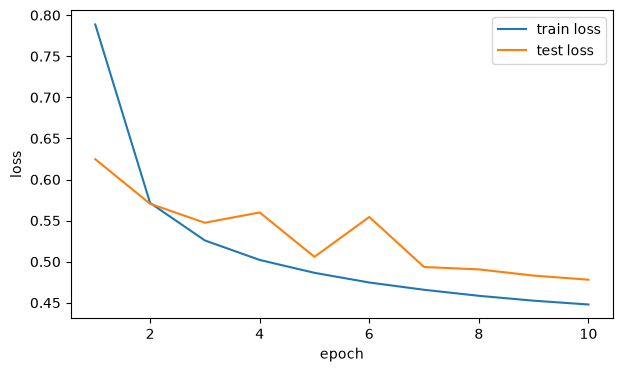

In [17]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    train_loss_history,
    label="train loss"
)

plt.plot(
    epochs,
    test_loss_history,
    label="test loss"
)

plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

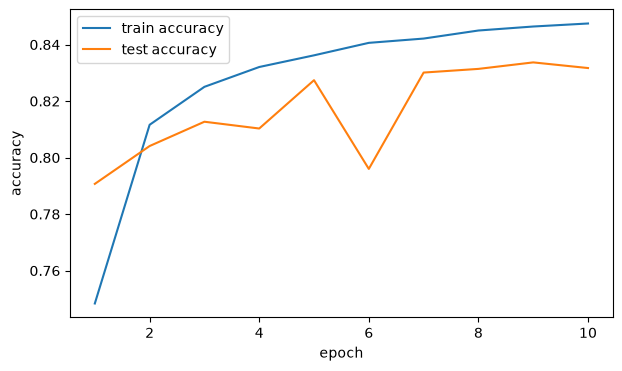

In [18]:
plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    train_acc_history,
    label="train accuracy"
)

plt.plot(
    epochs,
    test_acc_history,
    label="test accuracy"
)

plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

## 10. 예측 결과 확인

학습이 끝난 모델로 test image를 예측한다.

예측 class는 logits에서 가장 큰 값의 위치로 구한다. 

    predictions = logtis.argmax(dim=1)

확률까지 확인하고 싶다면 softmax를 적용한다.

    probabilities = torch.softmax(logits, dim=1)

예측: tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])
정답: tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])
확신도: tensor([0.6500, 0.9093, 0.9998, 0.9995, 0.6548, 0.9812, 0.9088, 0.7857, 0.5517,
        0.9703])


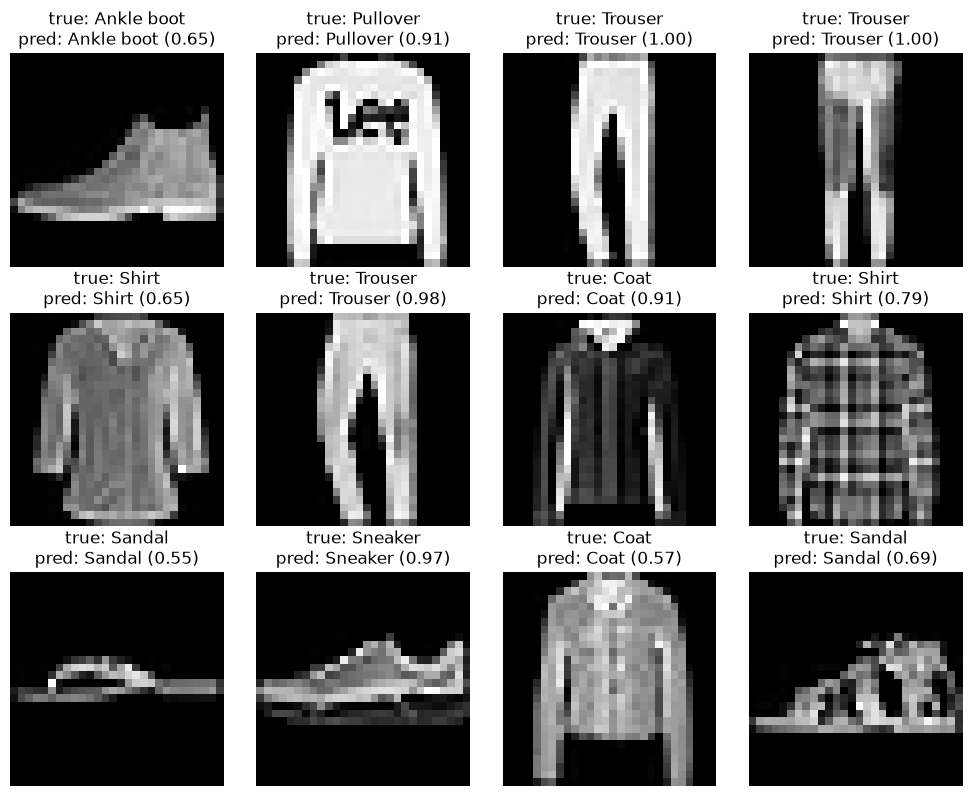

In [19]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

X_test, y_test = next(iter(test_loader))

model.eval()

with torch.no_grad():
    logits = model(X_test.to(device))

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    predictions = (
        logits.argmax(dim=1)
        .cpu()
    )

    confidence = (
        probabilities.max(dim=1)
        .values
        .cpu()
    )

print("예측:", predictions[:10])
print("정답:", y_test[:10])
print("확신도:", confidence[:10])

num_images = 12

fig, axes = plt.subplots(
    3,
    4,
    figsize=(10, 8)
)

axes = axes.flatten()

for i in range(num_images):
    true_name = class_names[
        y_test[i].item()
    ]

    predicted_name = class_names[
        predictions[i].item()
    ]

    predicted_probability = confidence[i].item()

    axes[i].imshow(
        X_test[i].squeeze(0),
        cmap="gray"
    )

    axes[i].set_title(
        f"true: {true_name}\n"
        f"pred: {predicted_name} "
        f"({predicted_probability:.2f})"
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 13. 오늘의 정리 

- 간결 구현은 직접 구현한 softmax regression과 같은 모델이다. 
- `nn.Flatten()`은 batch 차원을 유지하면서 나머지 차원을 하나로 합친다. 
- Flatten 이후 feature 수는 `channel × height × width`이다. 
- Fashion-MNIST는 `[1, 28, 28]` 이미지이므로 784개 feature가 된다. 
- 따라서 이번 모델에서는 `nn.Linear(784, 10)`을 사용한다.
- `nn.Linear(784, 10)`은 `XW + b`를 계산한다. 
- 모델의 출력은 확률이 아니라 logits이다. 
- Logits의 shape은 `[batch_size, 10]`이다. 
- `nn.CrossEntropyLoss()`에는 logits를 직접 전달한다. 
- CrossEntropyLoss를 사용할 때 모델에 softmax를 넣으면 안 된다. 
- CrossEntropyLoss는 softmax와 log 계산을 안정적으로 결합한다. 
- `torch.optim.SGD()`는 모델 파라미터를 업데이트한다. 
- `optimizer.zero_grad()`는 이전 gradient를 초기화한다. 
- `loss.backward()`는 gradient를 계산한다. 
- `optimizer.step()`은 weight와 bias를 업데이트한다. 
- 예측 class만 필요하면 logits에 바로 `argmax`를 사용한다. 
- class별 확률이 필요할 때만 `torch.softmax()`를 사용한다. 
- 직접 구현은 내부 원리를 이해하기 위해 필요하다. 
- 간결 구현은 실제 모델 개발에서 주로 사용하는 방식이다.